In [1]:
import pandas as pd
import plotly.express as px
from statsmodels.tsa.seasonal import seasonal_decompose
import logging
import datetime
import time

from datetime import datetime

from pyspark.sql.functions import col, datediff
import dash
from dash import dcc, html
from dash.dependencies import Input, Output

import calendar
import pandas as pd
import plotly.express as px
from pyspark.sql import SparkSession
from pyspark.sql.functions import concat, col
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from ipywidgets import interact, widgets
from matplotlib.dates import MonthLocator, DateFormatter
import geopandas as gpd
from shapely.geometry import Point
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import geopandas as gpd
from mpl_toolkits.axes_grid1 import make_axes_locatable
#from fbprophet import Prophet
from sklearn.metrics import mean_squared_error
import numpy as np
import plotly.graph_objects as go
from pyspark.sql import functions as F
from pyspark.sql.functions import year, month
from sklearn.metrics.pairwise import euclidean_distances
from pyspark.sql.functions import year, month, sum as sum_
from scipy.spatial.distance import euclidean
from prophet import Prophet
from pyspark.sql.functions import col, countDistinct , desc , count , length
from pyspark.sql.functions import split, col, when
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, udf, dayofmonth, last_day ,to_date, lit, isnull
from pyspark.sql.types import IntegerType
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
from dateutil.relativedelta import relativedelta
from pyspark.sql.functions import date_format

from pyspark.sql.functions import col, coalesce, current_date, months_between, round
from pyspark.sql.functions import regexp_replace

import schedule
from pyspark.sql.functions import col, to_timestamp, date_format

import pyspark
import pandas as pd
import boto3
import sagemaker
import sagemaker.feature_store.feature_store as fs
import databricks.connect
from dateutil.relativedelta import relativedelta

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from sklearn.metrics import mean_squared_error, root_mean_squared_error

import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import plotly.graph_objects as go
from itertools import product
import random
import statsmodels.api as sm
import os

from pyspark.sql import functions as F
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, months_between, current_date,expr
from pyspark.sql.functions import col, substr

import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
from databricks.connect import DatabricksSession


# Get spark
spark = databricks.connect.DatabricksSession.builder.getOrCreate()

c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packages\pydantic\_internal\_fields.py:192: UserWarning: Field name "json" in "MonitoringDatasetFormat" shadows an attribute in parent "Base"
  warnings.warn(


[02/20/25 14:12:54] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=55583;file://c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packages\botocore\credentials.py\credentials.py]8;;\:]8;id=4407;file://c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packages\botocore\credentials.py#1278\1278]8;;\

sagemaker.config INFO - Not applying SDK defaults from location: C:\ProgramData\sagemaker\sagemaker\config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: C:\Users\gusta\AppData\Local\sagemaker\sagemaker\config.yaml


In [2]:
spark.conf.set("spark.sql.legacy.timeParserPolicy", "LEGACY")

In [3]:
ltv = spark.table("dev.dw_rok.tb_ltv")

In [4]:
ltv.show()
ltv.count()

+---------+--------------+-------+-----------+----------+-----------+--------------------+------------------+---------------+----------------+-------+-------------------+--------------+------------+-----------+-------------+-------------------+-----+----------+--------------------------------------+-----------------------------------+-----------------------------------------+---------------------------------------+--------------+-------+--------------------+----+---------------------+-------+
|contratos|     documento|cliente|data_inicio|data_final|max_conexao|data_primeiro_boleto|data_ultimo_boleto|boletos_gerados|total_valor_pago|receita|         tipo_saida|meses_contrato|meses_boleto|anos_boleto|anos_contrato|boleto_gerados_anos|churn|ano_inicio|diferenca_meses_inicio_primeiro_boleto|diferenca_meses_final_ultimo_boleto|classifica_diferenca_boleto_tempo_inicial|classifica_diferenca_boleto_tempo_final|      CNPJ_CPF|CNAE_RF|          Hierarquia|  uf|data_inicio_atividade|empresa|
+---

130225

In [5]:
tabela_nova_df = ltv.toPandas()

In [6]:
print(tabela_nova_df.isnull().sum())

contratos                                        0
documento                                        0
cliente                                          0
data_inicio                                      0
data_final                                   13485
max_conexao                                  13485
data_primeiro_boleto                             0
data_ultimo_boleto                           13485
boletos_gerados                                  0
total_valor_pago                                 0
receita                                          0
tipo_saida                                       0
meses_contrato                                   0
meses_boleto                                     0
anos_boleto                                      0
anos_contrato                                    0
boleto_gerados_anos                              0
churn                                            0
ano_inicio                                       0
diferenca_meses_inicio_primeiro

### 2 anos

In [51]:
import pandas as pd
import matplotlib.pyplot as plt



# Converter a coluna 'data_primeiro_boleto' para datetime
tabela_nova_df['data_primeiro_boleto'] = pd.to_datetime(tabela_nova_df['data_primeiro_boleto'])

# Criar a coluna do ano do primeiro boleto
tabela_nova_df['ano_primeiro_boleto'] = tabela_nova_df['data_primeiro_boleto'].dt.year

# Agrupar por ano e calcular total, porcentagens de >=2 anos e <2 anos
tabela = tabela_nova_df.groupby('ano_primeiro_boleto').agg(
    total_registros=('anos_boleto', 'count'),
    porcentagem_maior_2=('anos_boleto', lambda x: (x >= 2).mean() * 100),
    porcentagem_menor_2=('anos_boleto', lambda x: (x < 2).mean() * 100)
).reset_index()

display(tabela)

import pandas as pd
import plotly.graph_objects as go



# Criar gráfico corrigido
fig = go.Figure()

# Adicionar barras para os clientes com >= 2 anos
fig.add_trace(go.Bar(
    x=tabela['ano_primeiro_boleto'], 
    y=tabela['porcentagem_maior_2'], 
    name=">= 2 anos", 
    marker_color='green'
))

# Adicionar barras para os clientes com < 2 anos (empilhadas)
fig.add_trace(go.Bar(
    x=tabela['ano_primeiro_boleto'], 
    y=tabela['porcentagem_menor_2'], 
    name="< 2 anos", 
    marker_color='red'
))

# Configurações do layout para corrigir eixo X
fig.update_layout(
    title="Retenção de Clientes por Ano do Primeiro Boleto (>=2 ano vs <2 ano)",
    xaxis_title="Ano do Primeiro Boleto",
    yaxis_title="Porcentagem (%)",
    xaxis=dict(
        tickmode='array',
        tickvals=tabela['ano_primeiro_boleto'].unique(),  # Apenas anos inteiros
        ticktext=[str(ano) for ano in tabela['ano_primeiro_boleto'].unique()]
    ),
    barmode='stack',
    legend_title="Tempo de Permanência"
)

# Exibir o gráfico
fig.show()


,ano_primeiro_boleto,total_registros,porcentagem_maior_2,porcentagem_menor_2
0,2002,5,100.000000,0.000000
1,2003,322,100.000000,0.000000
2,2004,148,100.000000,0.000000
3,2005,35,97.142857,2.857143
4,2006,14054,57.172335,42.827665
5,2007,4482,60.151718,39.848282
6,2008,9661,54.497464,45.502536
7,2009,10853,56.758500,43.241500
8,2010,7666,72.019306,27.980694
9,2011,8201,62.394830,37.605170


### 1 ano

In [45]:
import pandas as pd
import plotly.graph_objects as go

# Converter a coluna 'data_primeiro_boleto' para datetime
tabela_nova_df['data_primeiro_boleto'] = pd.to_datetime(tabela_nova_df['data_primeiro_boleto'])

# Criar a coluna do ano do primeiro boleto
tabela_nova_df['ano_primeiro_boleto'] = tabela_nova_df['data_primeiro_boleto'].dt.year

# Agrupar por ano e calcular total, porcentagens de >1 ano e <1 ano
tabela = tabela_nova_df.groupby('ano_primeiro_boleto').agg(
    total_registros=('anos_boleto', 'count'),
    porcentagem_maior_1=('anos_boleto', lambda x: (x >= 1).mean() * 100),
    porcentagem_menor_1=('anos_boleto', lambda x: (x < 1).mean() * 100)
).reset_index()

# Exibir a tabela
display(tabela)

# Criar gráfico corrigido para mostrar os tempos >1 ano e <1 ano
fig = go.Figure()

# Adicionar barras para os clientes com > 1 ano
fig.add_trace(go.Bar(
    x=tabela['ano_primeiro_boleto'].astype(str),  
    y=tabela['porcentagem_maior_1'], 
    name=">= 1 ano", 
    marker_color='green'
))

# Adicionar barras para os clientes com < 1 ano (empilhadas)
fig.add_trace(go.Bar(
    x=tabela['ano_primeiro_boleto'].astype(str),  
    y=tabela['porcentagem_menor_1'], 
    name="< 1 ano", 
    marker_color='red'
))

# Configurações do layout
fig.update_layout(
    title="Retenção de Clientes por Ano do Primeiro Boleto (>=1 ano vs <1 ano)",
    xaxis_title="Ano do Primeiro Boleto",
    yaxis_title="Porcentagem (%)",
    xaxis=dict(
        type='category',
        tickmode='array',
        tickvals=tabela['ano_primeiro_boleto'].astype(str),
        ticktext=[str(ano) for ano in tabela['ano_primeiro_boleto']]
    ),
    barmode='stack',
    legend_title="Tempo de Permanência"
)

# Exibir o gráfico
fig.show()


,ano_primeiro_boleto,total_registros,porcentagem_maior_1,porcentagem_menor_1
0,2002,5,100.000000,0.000000
1,2003,322,100.000000,0.000000
2,2004,148,100.000000,0.000000
3,2005,35,97.142857,2.857143
4,2006,14054,69.994308,30.005692
5,2007,4482,87.639447,12.360553
6,2008,9661,79.857158,20.142842
7,2009,10853,68.782825,31.217175
8,2010,7666,88.233759,11.766241
9,2011,8201,89.001341,10.998659


### 3 anos

In [48]:
import pandas as pd
import plotly.graph_objects as go

# Converter a coluna 'data_primeiro_boleto' para datetime
tabela_nova_df['data_primeiro_boleto'] = pd.to_datetime(tabela_nova_df['data_primeiro_boleto'])

# Criar a coluna do ano do primeiro boleto
tabela_nova_df['ano_primeiro_boleto'] = tabela_nova_df['data_primeiro_boleto'].dt.year

# Agrupar por ano e calcular total, porcentagens de >3 anos e <3 anos
tabela_3 = tabela_nova_df.groupby('ano_primeiro_boleto').agg(
    total_registros=('anos_boleto', 'count'),
    porcentagem_maior_3=('anos_boleto', lambda x: (x >= 3).mean() * 100),
    porcentagem_menor_3=('anos_boleto', lambda x: (x < 3).mean() * 100)
).reset_index()

# Exibir a tabela
display(tabela_3)

# Criar gráfico para 3 anos
fig_3 = go.Figure()

# Adicionar barras para os clientes com > 3 anos
fig_3.add_trace(go.Bar(
    x=tabela_3['ano_primeiro_boleto'].astype(str),  
    y=tabela_3['porcentagem_maior_3'], 
    name=">= 3 anos", 
    marker_color='green'
))

# Adicionar barras para os clientes com < 3 anos (empilhadas)
fig_3.add_trace(go.Bar(
    x=tabela_3['ano_primeiro_boleto'].astype(str),  
    y=tabela_3['porcentagem_menor_3'], 
    name="< 3 anos", 
    marker_color='red'
))

# Configurações do layout
fig_3.update_layout(
    title="Retenção de Clientes por Ano do Primeiro Boleto (>= 3 anos vs <3 anos)",
    xaxis_title="Ano do Primeiro Boleto",
    yaxis_title="Porcentagem (%)",
    xaxis=dict(
        type='category',
        tickmode='array',
        tickvals=tabela_3['ano_primeiro_boleto'].astype(str),
        ticktext=[str(ano) for ano in tabela_3['ano_primeiro_boleto']]
    ),
    barmode='stack',
    legend_title="Tempo de Permanência"
)

# Exibir o gráfico
fig_3.show()


,ano_primeiro_boleto,total_registros,porcentagem_maior_3,porcentagem_menor_3
0,2002,5,100.000000,0.000000
1,2003,322,100.000000,0.000000
2,2004,148,100.000000,0.000000
3,2005,35,97.142857,2.857143
4,2006,14054,40.685926,59.314074
5,2007,4482,42.838019,57.161981
6,2008,9661,47.966049,52.033951
7,2009,10853,49.534691,50.465309
8,2010,7666,51.747978,48.252022
9,2011,8201,47.896598,52.103402


### 4 anos

In [49]:
import pandas as pd
import plotly.graph_objects as go

# Converter a coluna 'data_primeiro_boleto' para datetime
tabela_nova_df['data_primeiro_boleto'] = pd.to_datetime(tabela_nova_df['data_primeiro_boleto'])

# Criar a coluna do ano do primeiro boleto
tabela_nova_df['ano_primeiro_boleto'] = tabela_nova_df['data_primeiro_boleto'].dt.year

# Agrupar por ano e calcular total, porcentagens de >4 anos e <4 anos
tabela_4 = tabela_nova_df.groupby('ano_primeiro_boleto').agg(
    total_registros=('anos_boleto', 'count'),
    porcentagem_maior_4=('anos_boleto', lambda x: (x >= 4).mean() * 100),
    porcentagem_menor_4=('anos_boleto', lambda x: (x < 4).mean() * 100)
).reset_index()

# Exibir a tabela
display(tabela_4)

# Criar gráfico para 4 anos
fig_4 = go.Figure()

# Adicionar barras para os clientes com > 4 anos
fig_4.add_trace(go.Bar(
    x=tabela_4['ano_primeiro_boleto'].astype(str),  
    y=tabela_4['porcentagem_maior_4'], 
    name=">= 4 anos", 
    marker_color='green'
))

# Adicionar barras para os clientes com < 4 anos (empilhadas)
fig_4.add_trace(go.Bar(
    x=tabela_4['ano_primeiro_boleto'].astype(str),  
    y=tabela_4['porcentagem_menor_4'], 
    name="< 4 anos", 
    marker_color='red'
))

# Configurações do layout
fig_4.update_layout(
    title="Retenção de Clientes por Ano do Primeiro Boleto (>=4 anos vs <4 anos)",
    xaxis_title="Ano do Primeiro Boleto",
    yaxis_title="Porcentagem (%)",
    xaxis=dict(
        type='category',
        tickmode='array',
        tickvals=tabela_4['ano_primeiro_boleto'].astype(str),
        ticktext=[str(ano) for ano in tabela_4['ano_primeiro_boleto']]
    ),
    barmode='stack',
    legend_title="Tempo de Permanência"
)

# Exibir o gráfico
fig_4.show()


,ano_primeiro_boleto,total_registros,porcentagem_maior_4,porcentagem_menor_4
0,2002,5,100.000000,0.000000
1,2003,322,100.000000,0.000000
2,2004,148,100.000000,0.000000
3,2005,35,97.142857,2.857143
4,2006,14054,26.540487,73.459513
5,2007,4482,37.862561,62.137439
6,2008,9661,42.293758,57.706242
7,2009,10853,32.774348,67.225652
8,2010,7666,40.255674,59.744326
9,2011,8201,39.007438,60.992562


#### Comparação Modelo Boletos (analise de sobrevivencia)

In [88]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from lifelines import KaplanMeierFitter, WeibullFitter, CoxPHFitter

def analisar_sobrevivencia_comparada_boletos(df):
    resultados = {"Ano": [], "Kaplan-Meier": [], "Weibull": [], "Cox": []}
    
    df["data_inicio"] = pd.to_datetime(df["data_inicio"])
    df["data_primeiro_boleto"] = pd.to_datetime(df["data_primeiro_boleto"])
    
    for ano_filtro in range(2006, 2025):
        print(f"Agora rodando para o ano {ano_filtro}...")
        
        
        df_filtrado = df[(df['data_primeiro_boleto'].dt.year >= ano_filtro)]
        
        df_filtrado["anos_boleto"] = df_filtrado["anos_boleto"].astype(float)
        df_filtrado["churn"] = df_filtrado["churn"].astype(int)
        
        if df_filtrado.empty:
            continue
        
        resultados["Ano"].append(ano_filtro)
        
        # Kaplan-Meier
        kmf = KaplanMeierFitter()
        kmf.fit(df_filtrado["anos_boleto"], event_observed=df_filtrado["churn"])
        tempo_km = np.trapz(kmf.survival_function_["KM_estimate"], kmf.survival_function_.index)
        resultados["Kaplan-Meier"].append(tempo_km)
        
        # Weibull
        wf = WeibullFitter()
        wf.fit(df_filtrado["anos_boleto"], event_observed=df_filtrado["churn"])
        tempo_weibull = wf.lambda_ * np.math.gamma(1 + 1 / wf.rho_)
        resultados["Weibull"].append(tempo_weibull)
        
        # Cox
        colunas_cox = ["anos_boleto", "churn"]
        if all(col in df_filtrado.columns for col in colunas_cox):
            df_cox = df_filtrado[colunas_cox].dropna()
            if not df_cox.empty:
                cph = CoxPHFitter()
                cph.fit(df_cox, duration_col="anos_boleto", event_col="churn")
                tempo_cox = cph.predict_expectation(df_cox).mean()
                resultados["Cox"].append(tempo_cox)
            else:
                resultados["Cox"].append(None)
        else:
            resultados["Cox"].append(None)
    
    df_resultados = pd.DataFrame(resultados)
    
    # Plotando gráfico
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=df_resultados["Ano"].astype(str), y=df_resultados["Kaplan-Meier"],
                             mode="lines+markers", name="Kaplan-Meier", line=dict(color="blue")))
    fig.add_trace(go.Scatter(x=df_resultados["Ano"].astype(str), y=df_resultados["Weibull"],
                             mode="lines+markers", name="Weibull", line=dict(color="red")))
    fig.add_trace(go.Scatter(x=df_resultados["Ano"].astype(str), y=df_resultados["Cox"],
                             mode="lines+markers", name="Cox", line=dict(color="green")))
    fig.update_layout(
        title="Comparação do Tempo de Vida Esperado (Kaplan-Meier, Weibull, Cox) Boletos",
        xaxis_title="Ano de Início",
        yaxis_title="Tempo de Vida Esperado (anos)",
        template="plotly_white",
        legend_title="Modelos"
    )
    fig.show()
    
    return df_resultados


In [89]:
analisar_sobrevivencia_comparada_boletos(tabela_nova_df)

Agora rodando para o ano 2006...


C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\427995564.py:18: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\427995564.py:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\427995564.py:35: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



Agora rodando para o ano 2007...


C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\427995564.py:18: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\427995564.py:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\427995564.py:35: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



Agora rodando para o ano 2008...


...

Agora rodando para o ano 2022...


C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\427995564.py:18: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\427995564.py:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\427995564.py:35: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



Agora rodando para o ano 2023...
Agora rodando para o ano 2024...


C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\427995564.py:18: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\427995564.py:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\427995564.py:35: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\427995564.py:18

,Ano,Kaplan-Meier,Weibull,Cox
0,2006,3.722740,3.803778,3.697265
1,2007,3.720341,3.818884,3.693269
2,2008,3.668760,3.784276,3.641386
3,2009,3.585593,3.713838,3.557579
4,2010,3.537666,3.670082,3.507373
5,2011,3.425692,3.580448,3.395954
6,2012,3.303445,3.487252,3.274220
7,2013,3.246747,3.461976,3.215346
8,2014,3.190979,3.465747,3.158437
9,2015,3.122819,3.463787,3.088427


### Janela Móvel

In [90]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from lifelines import KaplanMeierFitter, WeibullFitter, CoxPHFitter

def analisar_sobrevivencia_comparada_boletos_janela(df, ano_inicio, ano_fim):
    resultados = {"Ano": [], "Kaplan-Meier": [], "Weibull": [], "Cox": []}
    
    df["data_inicio"] = pd.to_datetime(df["data_inicio"])
    df["data_primeiro_boleto"] = pd.to_datetime(df["data_primeiro_boleto"])
    
    for ano_filtro in range(ano_inicio, ano_fim + 1):
        print(f"Agora rodando para os dados de {ano_filtro} até {ano_fim}...")

        # Aqui garantimos que estamos pegando os dados entre ano_filtro e ano_fim
        df_filtrado = df[
                (df['data_primeiro_boleto'].dt.year >= ano_filtro) & 
                (df['data_primeiro_boleto'].dt.year <= ano_fim)  # Agora mantém censurados corretamente
            ]
        
        df_filtrado["anos_boleto"] = df_filtrado["anos_boleto"].astype(float)
        df_filtrado["churn"] = df_filtrado["churn"].astype(int)
        
        if df_filtrado.empty:
            continue
        
        resultados["Ano"].append(ano_filtro)
        
        # Kaplan-Meier
        kmf = KaplanMeierFitter()
        kmf.fit(df_filtrado["anos_boleto"], event_observed=df_filtrado["churn"])
        tempo_km = np.trapz(kmf.survival_function_["KM_estimate"], kmf.survival_function_.index)
        resultados["Kaplan-Meier"].append(tempo_km)
        
        # Weibull
        wf = WeibullFitter()
        wf.fit(df_filtrado["anos_boleto"], event_observed=df_filtrado["churn"])
        tempo_weibull = wf.lambda_ * np.math.gamma(1 + 1 / wf.rho_)
        resultados["Weibull"].append(tempo_weibull)
        
        # Cox
        colunas_cox = ["anos_boleto", "churn"]
        if all(col in df_filtrado.columns for col in colunas_cox):
            df_cox = df_filtrado[colunas_cox].dropna()
            if not df_cox.empty:
                cph = CoxPHFitter()
                cph.fit(df_cox, duration_col="anos_boleto", event_col="churn")
                tempo_cox = cph.predict_expectation(df_cox).mean()
                resultados["Cox"].append(tempo_cox)
            else:
                resultados["Cox"].append(None)
        else:
            resultados["Cox"].append(None)
    
    df_resultados = pd.DataFrame(resultados)
    
    # Plotando gráfico
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=df_resultados["Ano"].astype(str), y=df_resultados["Kaplan-Meier"],
                             mode="lines+markers", name="Kaplan-Meier", line=dict(color="blue")))
    fig.add_trace(go.Scatter(x=df_resultados["Ano"].astype(str), y=df_resultados["Weibull"],
                             mode="lines+markers", name="Weibull", line=dict(color="red")))
    fig.add_trace(go.Scatter(x=df_resultados["Ano"].astype(str), y=df_resultados["Cox"],
                             mode="lines+markers", name="Cox", line=dict(color="green")))
    fig.update_layout(
        title=f"Comparação do Tempo de Vida Esperado (Kaplan-Meier, Weibull, Cox) Boletos ({ano_inicio}-{ano_fim})",
        xaxis_title="Ano de Início",
        yaxis_title="Tempo de Vida Esperado (anos)",
        template="plotly_white",
        legend_title="Modelos"
    )
    fig.show()
    
    return df_resultados


In [91]:
analisar_sobrevivencia_comparada_boletos_janela(tabela_nova_df, 2006, 2011)

Agora rodando para os dados de 2006 até 2011...


C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:38: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



Agora rodando para os dados de 2007 até 2011...


C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:38: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



Agora rodando para os dados de 2008 até 2011...


...

Agora rodando para os dados de 2010 até 2011...


C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:38: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



Agora rodando para os dados de 2011 até 2011...


C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:38: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



,Ano,Kaplan-Meier,Weibull,Cox
0,2006,4.065659,4.188840,4.040303
1,2007,4.228500,4.364307,4.198982
2,2008,4.179465,4.330789,4.150644
3,2009,4.113737,4.281882,4.084198
4,2010,4.331803,4.496331,4.292528
5,2011,4.197858,4.398277,4.160230


In [92]:
analisar_sobrevivencia_comparada_boletos_janela(tabela_nova_df, 2012, 2017)

Agora rodando para os dados de 2012 até 2017...


C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:38: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



Agora rodando para os dados de 2013 até 2017...


C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:38: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



Agora rodando para os dados de 2014 até 2017...


...

Agora rodando para os dados de 2016 até 2017...


C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:38: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



Agora rodando para os dados de 2017 até 2017...


C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:38: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



,Ano,Kaplan-Meier,Weibull,Cox
0,2012,3.342031,3.579674,3.313168
1,2013,3.283288,3.568474,3.251491
2,2014,3.231297,3.607296,3.198395
3,2015,3.194289,3.676282,3.159434
4,2016,3.249194,3.885417,3.210148
5,2017,3.508765,4.546298,3.463203


In [93]:
analisar_sobrevivencia_comparada_boletos_janela(tabela_nova_df, 2018, 2024)

Agora rodando para os dados de 2018 até 2024...


C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:38: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



Agora rodando para os dados de 2019 até 2024...


C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:38: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



Agora rodando para os dados de 2020 até 2024...


...

Agora rodando para os dados de 2021 até 2024...
Agora rodando para os dados de 2022 até 2024...


C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:38: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.p

Agora rodando para os dados de 2023 até 2024...
Agora rodando para os dados de 2024 até 2024...


C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\1817528734.py:38: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



,Ano,Kaplan-Meier,Weibull,Cox
0,2018,2.685161,3.146555,2.642737
1,2019,2.538503,3.085214,2.491977
2,2020,2.322801,2.888195,2.272113
3,2021,2.105644,2.750820,2.049041
4,2022,1.799472,2.478862,1.737412
5,2023,1.403405,2.182786,1.336133
6,2024,0.804752,1.245005,0.735551


In [32]:
analisar_sobrevivencia_comparada_boletos_janela(tabela_nova_df, 2018, 2024)

Agora rodando para os dados de 2018 até 2024...


C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\468655037.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\468655037.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\468655037.py:38: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



Agora rodando para os dados de 2019 até 2024...


C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\468655037.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\468655037.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\468655037.py:38: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



Agora rodando para os dados de 2020 até 2024...


...

Agora rodando para os dados de 2022 até 2024...
Agora rodando para os dados de 2023 até 2024...


C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\468655037.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\468655037.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\468655037.py:38: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\468655037.py:21

Agora rodando para os dados de 2024 até 2024...


C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\468655037.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\468655037.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\468655037.py:38: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



,Ano,Kaplan-Meier,Weibull,Cox
0,2018,2.685161,3.146555,2.248107
1,2019,2.538503,3.085214,2.107995
2,2020,2.322801,2.888195,1.918032
3,2021,2.105644,2.750820,1.728535
4,2022,1.799472,2.478862,1.490283
5,2023,1.403405,2.182786,1.165262
6,2024,0.804752,1.245005,0.663407


In [59]:
import plotly.graph_objects as go
import pandas as pd

def plotar_distribuicao_permanencia(sdf, coluna_anos="anos_contrato", coluna_tipo_saida="tipo_saida"):
    """
    Gera um gráfico de barras mostrando a distribuição do tempo de permanência dos clientes cancelados.

    Parâmetros:
    sdf (DataFrame do Spark): DataFrame contendo as colunas de anos de contrato e status de saída.
    coluna_anos (str): Nome da coluna que contém a quantidade de anos do contrato.
    coluna_tipo_saida (str): Nome da coluna que contém o tipo de saída do cliente.

    Retorno:
    None (exibe o gráfico interativo com Plotly)
    """
    
    import pandas as pd

    # Filtrar os clientes cancelados
    df_filtrado = sdf[sdf[coluna_tipo_saida] != "ATIVO"]

    # Selecionar apenas a coluna de anos para visualização
    df_permanencia = df_filtrado[[coluna_anos]]




    # Definir as faixas de tempo de permanência em anos
    bins = [0, 1, 2, 3, 4, 5, 6, 8, 10, df_permanencia[coluna_anos].max()]
    labels = [
        "0-1 ano",
        "1-2 anos",
        "2-3 anos",
        "3-4 anos",
        "4-5 anos",
        "5-6 anos",
        "6-8 anos",
        "8-10 anos",
        "10+ anos"
    ]

    # Criar coluna categórica com os intervalos
    df_permanencia["faixa_permanencia"] = pd.cut(df_permanencia[coluna_anos], bins=bins, labels=labels, right=True)

    # Contar a frequência de cada faixa
    df_faixas_status = df_permanencia["faixa_permanencia"].value_counts().reset_index()
    df_faixas_status.columns = ["faixa_permanencia", "frequencia"]
    df_faixas_status = df_faixas_status.sort_values(by="faixa_permanencia")  # Ordenar categorias

    # Criar gráfico de barras
    fig = go.Figure()

    fig.add_trace(go.Bar(
        x=df_faixas_status["faixa_permanencia"],
        y=df_faixas_status["frequencia"],
        name="Frequência",
        marker_color="red"
    ))

    # Configurar layout do gráfico
    fig.update_layout(
        title="Distribuição do Tempo de Permanência dos Clientes Cancelados por Faixa (anos) - Boletos",
        xaxis_title="Faixa de Tempo de Permanência (anos)",
        yaxis_title="Frequência",
        template="plotly_white"
    )

    # Exibir gráfico
    fig.show()


In [54]:
plotar_distribuicao_permanencia(tabela_nova_df, coluna_anos="anos_contrato", coluna_tipo_saida="tipo_saida")

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\3896440037.py:43: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [60]:
plotar_distribuicao_permanencia(tabela_nova_df, coluna_anos="anos_boleto", coluna_tipo_saida="tipo_saida")

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\321661708.py:43: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [67]:
import plotly.graph_objects as go
import pandas as pd

def plotar_distribuicao_permanencia(sdf, coluna_anos_contrato="anos_contrato", coluna_anos_boleto="anos_boleto", coluna_tipo_saida="tipo_saida"):
    """
    Gera um gráfico de barras comparando a distribuição do tempo de permanência dos clientes cancelados
    para as colunas `anos_contrato` e `anos_boleto`.

    Parâmetros:
    sdf (DataFrame do Spark): DataFrame contendo as colunas de anos de contrato, anos de boleto e status de saída.
    coluna_anos_contrato (str): Nome da coluna que contém a quantidade de anos do contrato.
    coluna_anos_boleto (str): Nome da coluna que contém a quantidade de anos do boleto.
    coluna_tipo_saida (str): Nome da coluna que contém o tipo de saída do cliente.

    Retorno:
    None (exibe o gráfico interativo com Plotly)
    """
    
    # Converter para Pandas e filtrar os clientes cancelados
    df_filtrado = sdf[sdf[coluna_tipo_saida] != "ATIVO"]

    # Definir as faixas de tempo de permanência em anos
    bins = [0, 1, 2, 3, 4, 5, 6, 8, 10, df_filtrado[[coluna_anos_contrato, coluna_anos_boleto]].max().max()]
    labels = [
        "0-1 ano",
        "1-2 anos",
        "2-3 anos",
        "3-4 anos",
        "4-5 anos",
        "5-6 anos",
        "6-8 anos",
        "8-10 anos",
        "10+ anos"
    ]

    # Criar colunas categóricas com os intervalos
    df_filtrado["faixa_permanencia_contrato"] = pd.cut(df_filtrado[coluna_anos_contrato], bins=bins, labels=labels, right=True)
    df_filtrado["faixa_permanencia_boleto"] = pd.cut(df_filtrado[coluna_anos_boleto], bins=bins, labels=labels, right=True)

    # Contar a frequência de cada faixa para ambas as colunas, garantindo que todas as categorias existam
    df_faixas_contrato = df_filtrado["faixa_permanencia_contrato"].value_counts().reindex(labels, fill_value=0).reset_index()
    df_faixas_contrato.columns = ["faixa_permanencia", "frequencia_contrato"]

    df_faixas_boleto = df_filtrado["faixa_permanencia_boleto"].value_counts().reindex(labels, fill_value=0).reset_index()
    df_faixas_boleto.columns = ["faixa_permanencia", "frequencia_boleto"]

    # Mesclar os dois DataFrames para ter faixas alinhadas
    df_faixas = pd.merge(df_faixas_contrato, df_faixas_boleto, on="faixa_permanencia", how="outer").fillna(0)

    # Ordenar as categorias corretamente
    df_faixas["faixa_permanencia"] = pd.Categorical(df_faixas["faixa_permanencia"], categories=labels, ordered=True)
    df_faixas = df_faixas.sort_values(by="faixa_permanencia")

    # Criar gráfico de barras lado a lado
    fig = go.Figure()

    fig.add_trace(go.Bar(
        x=df_faixas["faixa_permanencia"],
        y=df_faixas["frequencia_contrato"],
        name="Anos Contrato",
        marker_color="blue"
    ))

    fig.add_trace(go.Bar(
        x=df_faixas["faixa_permanencia"],
        y=df_faixas["frequencia_boleto"],
        name="Anos Boleto",
        marker_color="red"
    ))

    # Configurar layout do gráfico
    fig.update_layout(
        title="Distribuição do Tempo de Permanência dos Clientes Cancelados por Faixa (anos)",
        xaxis_title="Faixa de Tempo de Permanência (anos)",
        yaxis_title="Frequência",
        barmode="group",  # Coloca as barras lado a lado
        template="plotly_white"
    )

    # Exibir gráfico
    fig.show()


In [68]:
plotar_distribuicao_permanencia(tabela_nova_df, coluna_anos_contrato="anos_contrato", coluna_anos_boleto="anos_boleto", coluna_tipo_saida="tipo_saida")

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\614927708.py:37: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_1800\614927708.py:38: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [75]:
from pyspark.sql import functions as F
import pandas as pd
import plotly.graph_objects as go

def calcular_taxa_churn_anual_datas(df, coluna_primeiro_boleto="data_primeiro_boleto", coluna_ultimo_boleto="data_ultimo_boleto"):
    """
    Calcula a taxa de churn anual com base no ano de início do contrato e gera um gráfico interativo.

    Parâmetros:
    df (DataFrame): DataFrame do Pandas contendo as colunas 'data_primeiro_boleto' e 'data_ultimo_boleto'.

    Retorno:
    None (exibe o gráfico interativo com Plotly)
    """

    # Converter para datetime
    df[coluna_primeiro_boleto] = pd.to_datetime(df[coluna_primeiro_boleto])

    # Criar a coluna do ano de início do contrato
    df["ano_inicio"] = df[coluna_primeiro_boleto].dt.year

    # Contar o total de clientes por ano de início
    df_churn_anual = df.groupby("ano_inicio").agg(
        total_clientes=("ano_inicio", "count"),
        contratos_cancelados=(coluna_ultimo_boleto, lambda x: x.notnull().sum())  # Contar contratos com data de último boleto preenchida
    ).reset_index()

    # Calcular a taxa de churn
    df_churn_anual["taxa_churn"] = (df_churn_anual["contratos_cancelados"] / df_churn_anual["total_clientes"]) * 100

    # Criar gráfico interativo com Plotly
    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=df_churn_anual["ano_inicio"],
        y=df_churn_anual["taxa_churn"],
        marker_color="red",
        name="Taxa de Churn (%)"
    ))

    # Ajustes de layout
    fig.update_layout(
        title="Taxa de Churn por Início de Contrato (Boletos)",
        xaxis_title="Ano de Início do Contrato",
        yaxis_title="Taxa de Churn (%)",
        template="plotly_white",
        xaxis=dict(tickmode="linear")
    )

    # Exibir o gráfico
    fig.show()



calcular_taxa_churn_anual_datas(tabela_nova_df)

In [77]:
pd.set_option('display.max_columns', None)


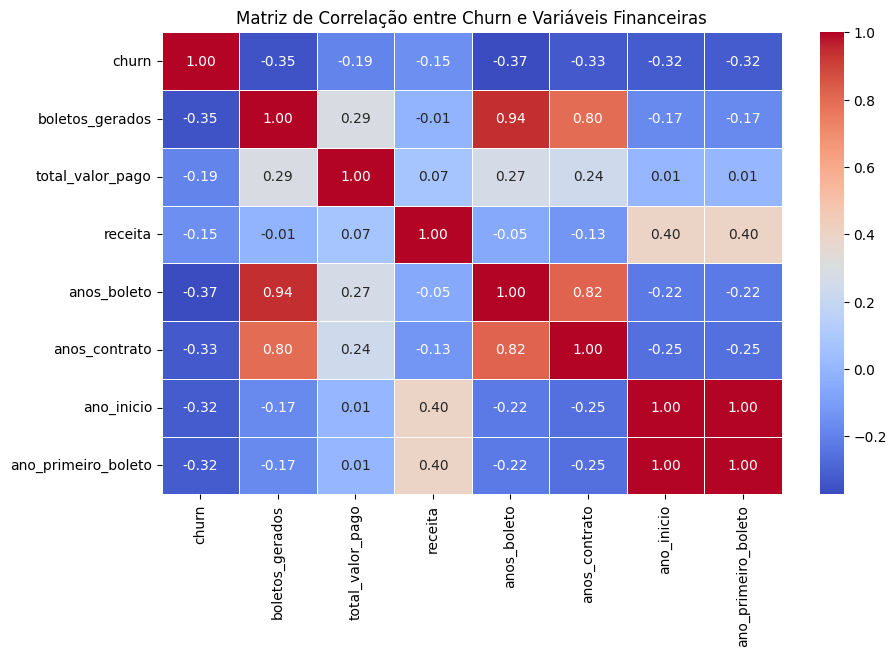

In [79]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionar apenas as colunas relevantes para a matriz de correlação
colunas_corr = ["churn", "boletos_gerados", "total_valor_pago", "receita", 
                "anos_boleto", "anos_contrato", "ano_inicio", "ano_primeiro_boleto"]

# Filtrar o DataFrame
df_corr = tabela_nova_df[colunas_corr].copy()

# Calcular a matriz de correlação
matriz_correlacao = df_corr.corr()

# Criar um heatmap da matriz de correlação
plt.figure(figsize=(10, 6))
sns.heatmap(matriz_correlacao, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Matriz de Correlação entre Churn e Variáveis Financeiras")
plt.show()


In [78]:
display(tabela_nova_df)

,contratos,documento,cliente,data_inicio,data_final,max_conexao,data_primeiro_boleto,data_ultimo_boleto,boletos_gerados,total_valor_pago,receita,tipo_saida,meses_contrato,meses_boleto,anos_boleto,anos_contrato,boleto_gerados_anos,churn,ano_inicio,diferenca_meses_inicio_primeiro_boleto,diferenca_meses_final_ultimo_boleto,classifica_diferenca_boleto_tempo_inicial,classifica_diferenca_boleto_tempo_final,CNPJ_CPF,CNAE_RF,Hierarquia,uf,data_inicio_atividade,empresa,ano_primeiro_boleto
0,1,00012212000199,435133,2019-04-12,2019-12-23,0,2019-05-01,2020-01-01,9,436.5,58,90 DIAS BLOQUEADO,8.0,8,0.67,0.67,0.75,1,2019,1,1,0 a 1 mês,0 a 1 mês,00012212000199,4781400,Comércio; Comércio varejista; Vestuário e aces...,SP,19940531,RedeOk,2019
1,1,00048587052934,456041,2005-06-28,2019-03-06,0,2017-10-01,2019-03-01,18,866.9,10,90 DIAS BLOQUEADO,164.0,17,1.42,13.67,1.50,1,2017,148,0,Maior que 24 meses,0 a 1 mês,None,None,None,None,None,Express,2017
2,1,00071260000158,166252,2006-01-25,2008-06-30,-1,2006-02-01,2008-06-01,21,681.2,9,CANCELAMENTO NORMAL,29.0,28,2.33,2.42,1.75,1,2006,1,0,0 a 1 mês,0 a 1 mês,00071260000158,8640213,Serviços; Saúde,MT,19940519,RedeOk,2006
3,1,00076958000166,436692,2019-06-04,2023-11-22,-1,2019-07-01,2023-11-01,53,3631.6,9,CANCELAMENTO NORMAL,54.0,52,4.33,4.50,4.42,1,2019,1,0,0 a 1 mês,0 a 1 mês,00076958000166,4751201,Comércio; Comércio varejista; Informática e co...,MT,19940526,RedeOk,2019
4,1,00082998000110,423039,2018-01-18,2018-12-19,0,2018-02-01,2019-03-01,14,910.0,9,90 DIAS BLOQUEADO,11.0,13,1.08,0.92,1.17,1,2018,1,3,0 a 1 mês,2 a 5 meses,00082998000110,2930101,Indústria; Indústrias de Transformação; Automo...,PR,19940606,RedeOk,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130220,1,97519184000132,363428,2014-12-29,2015-06-29,-1,2015-01-01,2015-06-01,6,264.0,58,CANCELAMENTO NORMAL,6.0,5,0.42,0.50,0.50,1,2015,1,0,0 a 1 mês,0 a 1 mês,97519184000132,8291100,Serviços; Serviços Administrativos; Escritório,MG,20110708,RedeOk,2015
130221,1,97534145000104,320997,2013-05-18,2016-02-29,-1,2013-06-01,2016-01-01,29,1812.8,9,CANCELAMENTO NORMAL,33.0,31,2.58,2.75,2.42,1,2013,1,1,0 a 1 mês,0 a 1 mês,97534145000104,4646001,Comércio; Comércio atacadista; Cosméticos,PB,20110707,RedeOk,2013
130222,1,97547696000102,298805,2012-04-19,2014-01-15,-1,2012-05-01,2013-12-05,16,374.2,9,CANCELAMENTO NORMAL,21.0,20,1.67,1.75,1.33,1,2012,1,1,0 a 1 mês,0 a 1 mês,97547696000102,9602501,Serviços; Serviços Diversos; Serviços pessoais,PR,20110713,RedeOk,2012
130223,1,98042120000660,67870,2002-09-06,2015-01-27,-1,2006-02-01,2006-05-01,3,39.0,9,CANCELAMENTO NORMAL,149.0,3,0.25,12.42,0.25,1,2006,41,104,Maior que 24 meses,Maior que 24 meses,98042120000660,4731800,Comércio; Comércio varejista; Combustíveis,RS,19731123,RedeOk,2006


In [80]:
import pandas as pd
import plotly.express as px

# Criar a contagem agrupada por empresa, churn e ano do primeiro boleto
tabela_contagem = tabela_nova_df.groupby(['empresa', 'churn', 'ano_primeiro_boleto']).size().reset_index(name='quantidade')

# Exibir a tabela resultante
display(tabela_contagem)

# Criar um gráfico interativo para visualizar os dados
fig = px.bar(
    tabela_contagem,
    x='ano_primeiro_boleto',
    y='quantidade',
    color='churn',
    facet_col='empresa',
    barmode='group',
    title="Distribuição de Churn por Empresa e Ano do Primeiro Boleto",
    labels={'ano_primeiro_boleto': 'Ano do Primeiro Boleto', 'quantidade': 'Quantidade', 'churn': 'Churn'}
)

# Exibir o gráfico
fig.show()


,empresa,churn,ano_primeiro_boleto,quantidade
0,Autofax,0,2002,2
1,Autofax,0,2003,183
2,Autofax,0,2004,95
3,Autofax,0,2005,20
4,Autofax,0,2006,22
...,...,...,...,...
96,RedeOk,1,2021,2013
97,RedeOk,1,2022,1391
98,RedeOk,1,2023,1090
99,RedeOk,1,2024,719


In [87]:
import pandas as pd
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Assumindo que tabela_nova_df já existe
# Criar a contagem agrupada 
tabela_contagem = tabela_nova_df.groupby(['empresa', 'churn', 'ano_primeiro_boleto']).size().reset_index(name='quantidade')

# Solução 1: Subplots com escalas independentes
fig = px.bar(
    tabela_contagem,
    x='ano_primeiro_boleto',
    y='quantidade',
    color='churn',
    facet_col='empresa',
    barmode='stack',
    title="Distribuição de Churn por Empresa e Ano do Primeiro Boleto",
    labels={'ano_primeiro_boleto': 'Ano do Primeiro Boleto', 'quantidade': 'Quantidade', 'churn': 'Churn'}
)

# Configurar escalas independentes para cada subplot
fig.update_yaxes(matches=None)

# Melhorar layout
fig.update_layout(
    height=500,
    width=1200,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

# Exibir o gráfico
fig.show()

# Solução 2: Normalizar por percentual
# Calcular o total por empresa e ano
totais = tabela_contagem.groupby(['empresa', 'ano_primeiro_boleto'])['quantidade'].sum().reset_index()
totais.rename(columns={'quantidade': 'total'}, inplace=True)

# Juntar com a tabela original
tabela_normalizada = pd.merge(tabela_contagem, totais, on=['empresa', 'ano_primeiro_boleto'])

# Calcular o percentual
tabela_normalizada['percentual'] = tabela_normalizada['quantidade'] / tabela_normalizada['total'] * 100

# Criar gráfico normalizado
fig_norm = px.bar(
    tabela_normalizada,
    x='ano_primeiro_boleto',
    y='percentual',
    color='churn',
    facet_col='empresa',
    barmode='stack',
    title="Distribuição Percentual de Churn por Empresa e Ano do Primeiro Boleto",
    labels={'ano_primeiro_boleto': 'Ano do Primeiro Boleto', 
           'percentual': '% de Clientes', 
           'churn': 'Churn'}
)

# Configurar escala igual para todos os gráficos (de 0 a 100%)
fig_norm.update_yaxes(range=[0, 100])

# Melhorar layout
fig_norm.update_layout(
    height=500,
    width=1200,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig_norm.show()

In [85]:
import pandas as pd
import plotly.express as px

# Criar a contagem agrupada por empresa, churn e ano do primeiro boleto
tabela_contagem = tabela_nova_df.groupby(['empresa', 'churn', 'ano_primeiro_boleto']).size().reset_index(name='quantidade')

# Criar um gráfico interativo com escala logarítmica no eixo Y
fig = px.bar(
    tabela_contagem,
    x='ano_primeiro_boleto',
    y='quantidade',
    color='churn',
    facet_col='empresa',
    barmode='group',
    title="Distribuição de Churn por Empresa e Ano do Primeiro Boleto (Escala Logarítmica)",
    labels={'ano_primeiro_boleto': 'Ano do Primeiro Boleto', 'quantidade': 'Quantidade', 'churn': 'Churn'}
)

# Aplicar escala logarítmica no eixo Y
fig.update_layout(
    yaxis_type="log",
    yaxis=dict(tickvals=[1, 10, 100, 1000, 10000, 15000], tickformat=".0f")
)


# Exibir o gráfico
fig.show()


In [82]:
# Criar a nova tabela eliminando valores nulos da coluna 'hierarquia'
tabela_cnae = tabela_nova_df.dropna(subset=['Hierarquia'])

In [83]:
print(tabela_cnae.isnull().sum())

contratos                                        0
documento                                        0
cliente                                          0
data_inicio                                      0
data_final                                   13472
max_conexao                                  13472
data_primeiro_boleto                             0
data_ultimo_boleto                           13472
boletos_gerados                                  0
total_valor_pago                                 0
receita                                          0
tipo_saida                                       0
meses_contrato                                   0
meses_boleto                                     0
anos_boleto                                      0
anos_contrato                                    0
boleto_gerados_anos                              0
churn                                            0
ano_inicio                                       0
diferenca_meses_inicio_primeiro